# Stage 4 — Controlled Noise Generation + Audit

This notebook creates controlled noisy test sets from the verified clean `test.csv`.

Stage 4 does **not** train models and does **not** evaluate model performance. It only creates reproducible noisy test data and metadata for later stages.

Generated noise types:

1. `no_accent`
2. `domain_abbreviation`
3. `teencode_colloquial`
4. `typo`
5. `elongation`
6. `mixed_noise`


## 1. Imports and project paths

In [12]:
from pathlib import Path
from datetime import datetime
import json
import random
import sys

import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "04_noise_config.yaml"

from src.noise_generator import generate_noisy_dataset, summarize_noisy_dataset

print("Project root:", PROJECT_ROOT)
print("Config path:", CONFIG_PATH)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Config path: d:\project-ml-engineering\nlp-phobert-student-feedback\configs\04_noise_config.yaml


## 2. Load config and clean test split

In [13]:
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

source_split_path = PROJECT_ROOT / config["source_split_path"]

if not source_split_path.exists():
    raise FileNotFoundError(f"Missing clean test split: {source_split_path}")

test_df = pd.read_csv(source_split_path)

required_cols = ["id", "text", "sentiment_label", "topic_label"]
missing_cols = [col for col in required_cols if col not in test_df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns in test split: {missing_cols}")

output_config = config["output"]

NOISY_DIR = PROJECT_ROOT / output_config["noisy_dir"]
AUDIT_DIR = PROJECT_ROOT / output_config["audit_dir"]
TABLES_DIR = PROJECT_ROOT / output_config["reports_tables_dir"]
FIGURES_DIR = PROJECT_ROOT / output_config["reports_figures_dir"]
NOTES_DIR = PROJECT_ROOT / output_config["reports_notes_dir"]

for path in [NOISY_DIR, AUDIT_DIR, TABLES_DIR, FIGURES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Test shape:", test_df.shape)
display(test_df.head())
config


Test shape: (3166, 9)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,test_0,test,nói tiếng anh lưu loát .,2,positive,0,lecturer,24,6
1,test_1,test,giáo viên rất vui tính .,2,positive,0,lecturer,24,6
2,test_2,test,cô max có tâm .,2,positive,0,lecturer,15,5
3,test_3,test,"giảng bài thu hút , dí dỏm .",2,positive,0,lecturer,28,8
4,test_4,test,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,negative,0,lecturer,79,17


{'seed': 42,
 'source_split_path': 'data/processed/test.csv',
 'output': {'noisy_dir': 'data/noisy',
  'audit_dir': 'data/audit',
  'reports_tables_dir': 'reports/tables',
  'reports_figures_dir': 'reports/figures',
  'reports_notes_dir': 'reports/notes'},
 'tokenization': {'phobert_model_name': 'vinai/phobert-base',
  'use_phobert_tokenizer': True},
 'audit': {'sample_per_noise_type': 25},
 'severity': {'low_max_ratio': 0.2, 'medium_max_ratio': 0.4},
 'noise_types': ['no_accent',
  'domain_abbreviation',
  'teencode_colloquial',
  'typo',
  'elongation',
  'mixed_noise'],
 'domain_abbreviation': {'max_replacements_per_sentence': 2,
  'replacements': {'giảng viên': 'gv',
   'giáo viên': 'gv',
   'sinh viên': 'sv',
   'học sinh': 'hs',
   'học phần': 'hp',
   'môn học': 'mh',
   'bài tập': 'bt',
   'bài kiểm tra': 'bkt',
   'kiểm tra': 'kt',
   'thực hành': 'th',
   'lý thuyết': 'lt',
   'cơ sở vật chất': 'csvc',
   'phòng học': 'ph',
   'phòng máy': 'pm',
   'chương trình đào tạo': 'ct

## 3. Initialize PhoBERT subword counter

In [14]:
use_phobert_tokenizer = bool(config.get("tokenization", {}).get("use_phobert_tokenizer", True))
phobert_model_name = config.get("tokenization", {}).get("phobert_model_name", "vinai/phobert-base")

subword_counter_source = "whitespace_fallback"

if use_phobert_tokenizer:
    try:
        from transformers import AutoTokenizer

        tokenizer = AutoTokenizer.from_pretrained(
            phobert_model_name,
            use_fast=False,
        )

        def count_subwords(text: str) -> int:
            return len(tokenizer.tokenize(str(text)))

        subword_counter_source = phobert_model_name
        print("Loaded PhoBERT tokenizer:", phobert_model_name)

    except Exception as error:
        print("Could not load PhoBERT tokenizer. Using whitespace fallback.")
        print("Reason:", error)

        def count_subwords(text: str) -> int:
            return len(str(text).split())
else:
    def count_subwords(text: str) -> int:
        return len(str(text).split())

print("Subword counter source:", subword_counter_source)


Loaded PhoBERT tokenizer: vinai/phobert-base
Subword counter source: vinai/phobert-base


c:\Users\LENOVO\anaconda3\envs\nlp-phobert-feedback\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## 4. Generate noisy test sets

In [15]:
noise_types = config["noise_types"]

noisy_frames = {}
summary_rows = []

for noise_type in noise_types:
    print("\n" + "=" * 100)
    print("Generating:", noise_type)

    noisy_df = generate_noisy_dataset(
        df=test_df,
        noise_type=noise_type,
        config=config,
        subword_counter=count_subwords,
    )

    noisy_frames[noise_type] = noisy_df

    output_path = NOISY_DIR / f"04_test_{noise_type}.csv"
    noisy_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print("Saved:", output_path)

    summary = summarize_noisy_dataset(noisy_df)
    summary_rows.append(summary)

    display(noisy_df[[
        "id",
        "original_text",
        "noisy_text",
        "noise_type",
        "severity",
        "changed_token_ratio",
        "is_changed",
    ]].head(5))

noise_summary = pd.DataFrame(summary_rows)
noise_summary_path = TABLES_DIR / "04_noise_generation_summary.csv"
noise_summary.to_csv(noise_summary_path, index=False, encoding="utf-8-sig")

display(noise_summary.round(4))
print("Saved:", noise_summary_path)



Generating: no_accent
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\noisy\04_test_no_accent.csv


,id,original_text,noisy_text,noise_type,severity,changed_token_ratio,is_changed
0,test_0,nói tiếng anh lưu loát .,noi tieng anh luu loat .,no_accent,high,0.666667,True
1,test_1,giáo viên rất vui tính .,giao vien rat vui tinh .,no_accent,high,0.666667,True
2,test_2,cô max có tâm .,co max co tam .,no_accent,high,0.600000,True
3,test_3,"giảng bài thu hút , dí dỏm .","giang bai thu hut , di dom .",no_accent,high,0.625000,True
4,test_4,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giao vien khong giang day kien thuc , huong da...",no_accent,high,0.823529,True



Generating: domain_abbreviation
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\noisy\04_test_domain_abbreviation.csv


,id,original_text,noisy_text,noise_type,severity,changed_token_ratio,is_changed
0,test_0,nói tiếng anh lưu loát .,nói tiếng anh lưu loát .,domain_abbreviation,none,0.000000,False
1,test_1,giáo viên rất vui tính .,gv rất vui tính .,domain_abbreviation,medium,0.333333,True
2,test_2,cô max có tâm .,cô max có tâm .,domain_abbreviation,none,0.000000,False
3,test_3,"giảng bài thu hút , dí dỏm .","giảng bài thu hút , dí dỏm .",domain_abbreviation,none,0.000000,False
4,test_4,"giáo viên không giảng dạy kiến thức , hướng dẫ...","gv không giảng dạy kiến thức , hướng dẫn th tr...",domain_abbreviation,medium,0.235294,True



Generating: teencode_colloquial
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\noisy\04_test_teencode_colloquial.csv


...

,id,original_text,noisy_text,noise_type,severity,changed_token_ratio,is_changed
0,test_0,nói tiếng anh lưu loát .,nóiii tiếng anh lưu loát .,elongation,low,0.166667,True
1,test_1,giáo viên rất vui tính .,giáo viênnn rất vui tính .,elongation,low,0.166667,True
2,test_2,cô max có tâm .,cô maxxx có tâm .,elongation,low,0.200000,True
3,test_3,"giảng bài thu hút , dí dỏm .","giảnggg bài thu hút , dí dỏm .",elongation,low,0.125000,True
4,test_4,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giáo viên không giảng dạy kiến thức , hướng dẫ...",elongation,low,0.058824,True



Generating: mixed_noise
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\noisy\04_test_mixed_noise.csv


,id,original_text,noisy_text,noise_type,severity,changed_token_ratio,is_changed
0,test_0,nói tiếng anh lưu loát .,nói tiếng anh lưuuu loát .,mixed_noise,low,0.166667,True
1,test_1,giáo viên rất vui tính .,gv r vuiii tính .,mixed_noise,high,0.666667,True
2,test_2,cô max có tâm .,cô max có tâm .,mixed_noise,none,0.000000,False
3,test_3,"giảng bài thu hút , dí dỏm .","giảng bài thu húttt , dí dỏm .",mixed_noise,low,0.125000,True
4,test_4,"giáo viên không giảng dạy kiến thức , hướng dẫ...","gv k giảnggg dạy kiến thức , hướng dẫn thực hà...",mixed_noise,medium,0.235294,True


,noise_type,num_rows,num_changed_rows,changed_row_percentage,mean_changed_token_ratio,median_changed_token_ratio,max_changed_token_ratio,mean_subword_delta
0,no_accent,3166,3162,99.87,0.7583,0.7778,0.9615,3.5158
1,domain_abbreviation,3166,1530,48.33,0.0902,0.0000,0.8000,-0.0850
2,teencode_colloquial,3166,1541,48.67,0.0484,0.0000,0.4000,0.1775
3,typo,3166,3074,97.09,0.0956,0.0833,0.5000,0.5332
4,elongation,3166,3164,99.94,0.1019,0.0909,0.5000,2.1295
5,mixed_noise,3166,3135,99.02,0.2089,0.1818,0.8000,1.3714


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_generation_summary.csv


## 5. Severity distribution and changed-token-ratio summary

In [16]:
all_noisy = pd.concat(noisy_frames.values(), ignore_index=True)

severity_distribution = (
    all_noisy
    .groupby(["noise_type", "severity"])
    .size()
    .reset_index(name="count")
)

severity_distribution["percentage"] = (
    severity_distribution
    .groupby("noise_type")["count"]
    .transform(lambda s: s / s.sum() * 100)
    .round(2)
)

severity_distribution_path = TABLES_DIR / "04_noise_severity_distribution.csv"
severity_distribution.to_csv(
    severity_distribution_path,
    index=False,
    encoding="utf-8-sig",
)

ratio_summary = (
    all_noisy
    .groupby("noise_type")["changed_token_ratio"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

ratio_summary_path = TABLES_DIR / "04_changed_token_ratio_summary.csv"
ratio_summary.to_csv(
    ratio_summary_path,
    index=False,
    encoding="utf-8-sig",
)

display(severity_distribution)
display(ratio_summary.round(4))

print("Saved:", severity_distribution_path)
print("Saved:", ratio_summary_path)


,noise_type,severity,count,percentage
0,domain_abbreviation,high,23,0.73
1,domain_abbreviation,low,1001,31.62
2,domain_abbreviation,medium,504,15.92
3,domain_abbreviation,none,1638,51.74
4,elongation,high,4,0.13
5,elongation,low,3020,95.39
6,elongation,medium,140,4.42
7,elongation,none,2,0.06
8,mixed_noise,high,227,7.17
9,mixed_noise,low,1859,58.72


,noise_type,count,mean,median,min,max
0,domain_abbreviation,3166,0.0902,0.0000,0.0,0.8000
1,elongation,3166,0.1019,0.0909,0.0,0.5000
2,mixed_noise,3166,0.2089,0.1818,0.0,0.8000
3,no_accent,3166,0.7583,0.7778,0.0,0.9615
4,teencode_colloquial,3166,0.0484,0.0000,0.0,0.4000
5,typo,3166,0.0956,0.0833,0.0,0.5000


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_severity_distribution.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_changed_token_ratio_summary.csv


## 6. Noise examples

In [17]:
example_frames = []

for noise_type, noisy_df in noisy_frames.items():
    changed_examples = noisy_df[noisy_df["is_changed"]].copy()

    if changed_examples.empty:
        examples = noisy_df.head(5).copy()
    else:
        examples = changed_examples.head(10).copy()

    example_frames.append(examples)

noise_examples = pd.concat(example_frames, ignore_index=True)

example_cols = [
    "id",
    "noise_type",
    "original_text",
    "noisy_text",
    "sentiment_label",
    "topic_label",
    "severity",
    "changed_token_ratio",
    "changed_spans",
]

noise_examples_path = TABLES_DIR / "04_noise_examples.csv"
noise_examples[example_cols].to_csv(
    noise_examples_path,
    index=False,
    encoding="utf-8-sig",
)

display(noise_examples[example_cols])
print("Saved:", noise_examples_path)


,id,noise_type,original_text,noisy_text,sentiment_label,topic_label,severity,changed_token_ratio,changed_spans
0,test_0,no_accent,nói tiếng anh lưu loát .,noi tieng anh luu loat .,positive,lecturer,high,0.666667,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
1,test_1,no_accent,giáo viên rất vui tính .,giao vien rat vui tinh .,positive,lecturer,high,0.666667,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
2,test_2,no_accent,cô max có tâm .,co max co tam .,positive,lecturer,high,0.600000,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
3,test_3,no_accent,"giảng bài thu hút , dí dỏm .","giang bai thu hut , di dom .",positive,lecturer,high,0.625000,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
4,test_4,no_accent,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giao vien khong giang day kien thuc , huong da...",negative,lecturer,high,0.823529,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
5,test_5,no_accent,thầy dạy nhiệt tình và tâm huyết .,thay day nhiet tinh va tam huyet .,positive,lecturer,high,0.875000,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
6,test_6,no_accent,tính điểm thi đua các nhóm .,tinh diem thi dua cac nhom .,positive,training_program,high,0.714286,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
7,test_7,no_accent,thầy nhiệt tình giảng lại cho học sinh .,thay nhiet tinh giang lai cho hoc sinh .,positive,lecturer,high,0.666667,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
8,test_8,no_accent,có đôi lúc nói hơi nhanh làm sinh viên không t...,co doi luc noi hoi nhanh lam sinh vien khong t...,negative,lecturer,high,0.692308,"[{""start_token"": 0, ""end_token"": 1, ""original""..."
9,test_9,no_accent,"giảng dạy nhiệt tình , liên hệ thực tế khá nhi...","giang day nhiet tinh , lien he thuc te kha nhi...",positive,lecturer,high,0.809524,"[{""start_token"": 0, ""end_token"": 1, ""original""..."


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_examples.csv


## 7. Create manual audit sample

In [18]:
sample_per_noise_type = int(config.get("audit", {}).get("sample_per_noise_type", 25))
audit_frames = []

for noise_type, noisy_df in noisy_frames.items():
    candidate_df = noisy_df[noisy_df["is_changed"]].copy()

    if candidate_df.empty:
        candidate_df = noisy_df.copy()

    sample_size = min(sample_per_noise_type, len(candidate_df))

    audit_sample = candidate_df.sample(
        n=sample_size,
        random_state=int(config.get("seed", 42)),
    ).copy()

    audit_frames.append(audit_sample)

audit_df = pd.concat(audit_frames, ignore_index=True)

audit_cols = [
    "id",
    "noise_type",
    "original_text",
    "noisy_text",
    "sentiment_label",
    "topic_label",
    "changed_token_ratio",
    "severity",
]

audit_df = audit_df[audit_cols].copy()
audit_df["preserve_meaning"] = ""
audit_df["label_still_valid"] = ""
audit_df["audit_note"] = ""

audit_path = AUDIT_DIR / "04_noise_audit_sample.csv"
audit_table_path = TABLES_DIR / "04_noise_audit_sample.csv"

audit_df.to_csv(audit_path, index=False, encoding="utf-8-sig")
audit_df.to_csv(audit_table_path, index=False, encoding="utf-8-sig")

display(audit_df.head(20))
print("Saved:", audit_path)
print("Saved:", audit_table_path)


,id,noise_type,original_text,noisy_text,sentiment_label,topic_label,changed_token_ratio,severity,preserve_meaning,label_still_valid,audit_note
0,test_139,no_accent,em rất hài lòng về phương pháp giảng dạy này .,em rat hai long ve phuong phap giang day nay .,positive,lecturer,0.818182,high,,,
1,test_864,no_accent,dạy sát kiến thức cho việc thi cử .,day sat kien thuc cho viec thi cu .,positive,lecturer,0.666667,high,,,
2,test_291,no_accent,sinh viên hiểu thầy mới cho về .,sinh vien hieu thay moi cho ve .,positive,lecturer,0.625000,high,,,
3,test_1243,no_accent,dạy hơi chán nhưng chắc tại môn giới thiệu ngà...,day hoi chan nhung chac tai mon gioi thieu nga...,negative,lecturer,0.947368,high,,,
4,test_599,no_accent,dạy kết hợp với các hoạt động liên quan đến bà...,day ket hop voi cac hoat dong lien quan den ba...,negative,lecturer,0.875000,high,,,
5,test_1237,no_accent,cần thêm bài tập ôn chuyên sâu hơn .,can them bai tap on chuyen sau hon .,negative,training_program,0.888889,high,,,
6,test_598,no_accent,giáo viên rất nhiệt tình .,giao vien rat nhiet tinh .,positive,lecturer,0.833333,high,,,
7,test_416,no_accent,nhà trường cần cải tiến thiết bị trong phòng h...,nha truong can cai tien thiet bi trong phong h...,negative,facility,0.875000,high,,,
8,test_314,no_accent,"giáo viên vui vẻ , giảng dạy nhiệt tình .","giao vien vui ve , giang day nhiet tinh .",positive,lecturer,0.700000,high,,,
9,test_1265,no_accent,"thầy chu đáo , vui vẻ , tận tình .","thay chu dao , vui ve , tan tinh .",positive,lecturer,0.500000,high,,,


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\audit\04_noise_audit_sample.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_audit_sample.csv


## 8. Figures

<Figure size 1000x500 with 0 Axes>

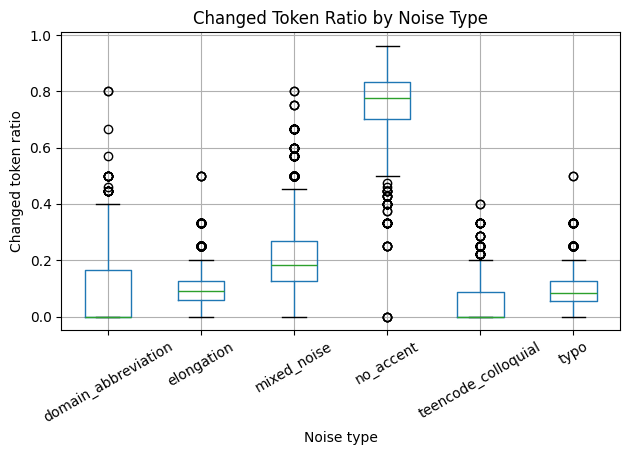

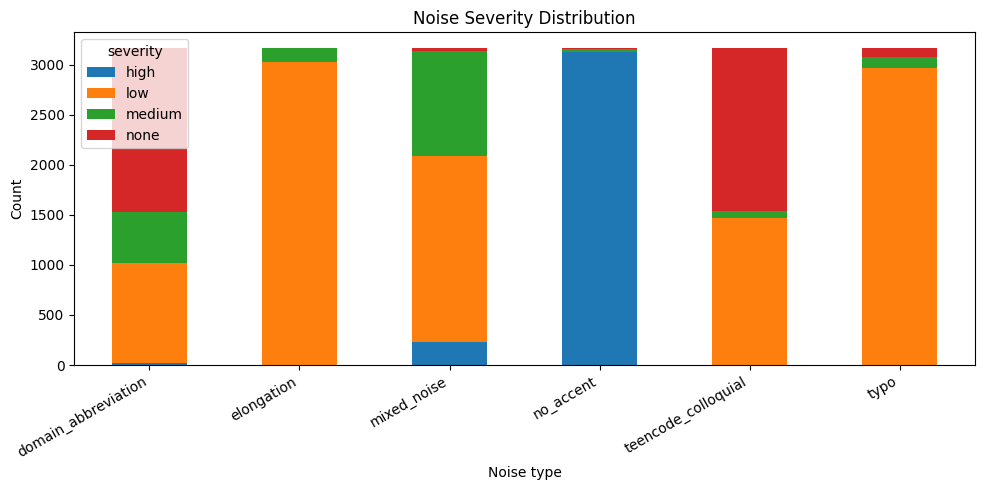

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\04_changed_token_ratio_by_noise_type.png
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\04_noise_severity_distribution.png


In [19]:
plt.figure(figsize=(10, 5))
all_noisy.boxplot(
    column="changed_token_ratio",
    by="noise_type",
    rot=30,
)
plt.title("Changed Token Ratio by Noise Type")
plt.suptitle("")
plt.xlabel("Noise type")
plt.ylabel("Changed token ratio")
plt.tight_layout()

ratio_fig_path = FIGURES_DIR / "04_changed_token_ratio_by_noise_type.png"
plt.savefig(ratio_fig_path, dpi=150)
plt.show()

severity_pivot = severity_distribution.pivot_table(
    index="noise_type",
    columns="severity",
    values="count",
    fill_value=0,
)

ax = severity_pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Noise Severity Distribution")
ax.set_xlabel("Noise type")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

severity_fig_path = FIGURES_DIR / "04_noise_severity_distribution.png"
plt.savefig(severity_fig_path, dpi=150)
plt.show()

print("Saved:", ratio_fig_path)
print("Saved:", severity_fig_path)


## 9. Generate Stage 4 report

In [20]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")

    return "\n".join(lines)


report_lines = []

report_lines.append("# Controlled Noise Generation and Audit Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Stage: `04_noise_generation_audit`")
report_lines.append(f"- Source split: `{source_split_path}`")
report_lines.append("- Noise is generated only from the clean test split.")
report_lines.append("- Original sentiment and topic labels are preserved.\n")

report_lines.append("## Noise types\n")
for noise_type in noise_types:
    report_lines.append(f"- `{noise_type}`")
report_lines.append("\n")

report_lines.append("## Metadata definitions\n")
report_lines.append("- `changed_token_ratio`: number of original whitespace tokens covered by changed spans divided by the number of original whitespace tokens.")
report_lines.append("- `severity`: `none`, `low`, `medium`, or `high` based on changed-token ratio.")
report_lines.append("- `changed_spans`: JSON string with original token span, original text, replacement text, and rule name.")
report_lines.append("- `num_subwords_clean` and `num_subwords_noisy`: counted with the configured PhoBERT tokenizer when available.\n")

report_lines.append("## Generation summary\n")
summary_display = noise_summary.copy()
for col in ["mean_changed_token_ratio", "median_changed_token_ratio", "max_changed_token_ratio", "mean_subword_delta"]:
    if col in summary_display.columns:
        summary_display[col] = summary_display[col].round(4)

report_lines.append(dataframe_to_markdown(summary_display))
report_lines.append("\n")

report_lines.append("## Severity distribution\n")
report_lines.append(dataframe_to_markdown(severity_distribution))
report_lines.append("\n")

report_lines.append("## Audit policy\n")
report_lines.append(f"- Audit sample per noise type: `{sample_per_noise_type}`")
report_lines.append("- The audit file contains empty columns for manual review: `preserve_meaning`, `label_still_valid`, and `audit_note`.")
report_lines.append("- Samples that clearly change meaning or invalidate the original label should be removed or used only for qualitative analysis.\n")

report_lines.append("## Limitations\n")
report_lines.append("- The noise rules are deterministic/reproducible but still heuristic.")
report_lines.append("- Some noise types may not affect every sentence because the required phrase or token pattern may be absent.")
report_lines.append("- Manual audit is required before treating all generated noisy samples as semantically valid.")
report_lines.append("- Model evaluation is not performed in Stage 4.\n")

report_path = NOTES_DIR / "04_noise_generation_audit_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\04_noise_generation_audit_report.md


## 10. Final Stage 4 output check

In [21]:
expected_files = [
    TABLES_DIR / "04_noise_generation_summary.csv",
    TABLES_DIR / "04_noise_severity_distribution.csv",
    TABLES_DIR / "04_changed_token_ratio_summary.csv",
    TABLES_DIR / "04_noise_examples.csv",
    TABLES_DIR / "04_noise_audit_sample.csv",
    FIGURES_DIR / "04_changed_token_ratio_by_noise_type.png",
    FIGURES_DIR / "04_noise_severity_distribution.png",
    NOTES_DIR / "04_noise_generation_audit_report.md",
    AUDIT_DIR / "04_noise_audit_sample.csv",
]

for noise_type in noise_types:
    expected_files.append(NOISY_DIR / f"04_test_{noise_type}.csv")

print("Stage 4 output check:")

all_ok = True
for path in expected_files:
    exists = path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", path)

print("\nStage 4 completed:", all_ok)


Stage 4 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_generation_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_severity_distribution.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_changed_token_ratio_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_examples.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\04_noise_audit_sample.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\04_changed_token_ratio_by_noise_type.png
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\04_noise_severity_distribution.png
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\04_noise_generation_audit_report.md
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\data\audit

## What to send for review

After this notebook finishes, send:

1. `reports/tables/04_noise_generation_summary.csv`
2. `reports/tables/04_changed_token_ratio_summary.csv`
3. `reports/tables/04_noise_examples.csv`
4. `reports/notes/04_noise_generation_audit_report.md`
5. Final output check
